In [1]:
from orbitx import Orbit
import numpy as np

C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py:141: UserWarning: The oldest TLE file is more recent than the start time requested.
 Oldest TLE file: 2020-11-22T19:06:03.724
 Start time requested: 2020-02-01T00:00:00
  warnings.warn(


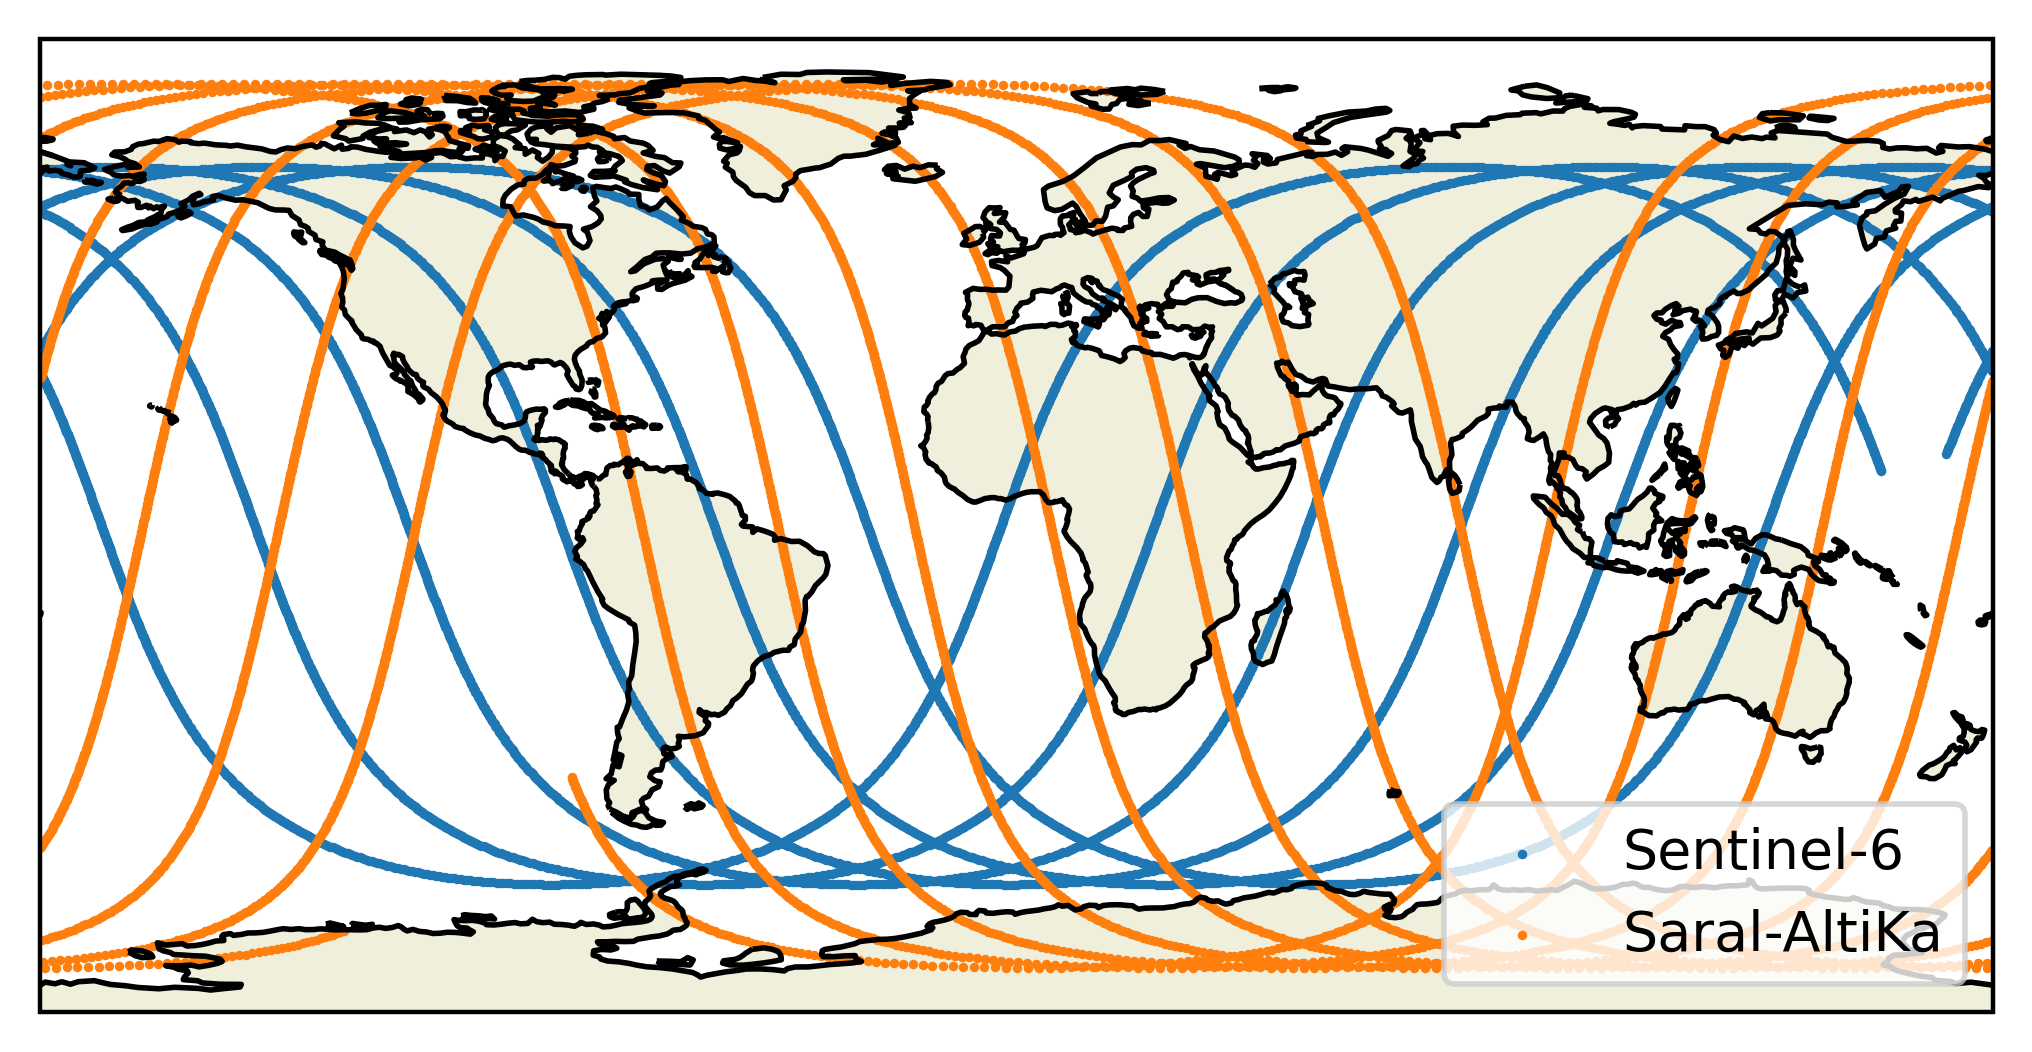

In [2]:
orbit = Orbit.simulate(
    satellites=["S6", "SA"],
    start_date=np.datetime64("2020-02-01T00:00:00"),
    end_date=np.datetime64("2020-02-01T12:00:00"),
    propagation_sampling_interval=np.array([20], dtype="timedelta64[s]")[0],
    interpolation_sampling_interval=np.array([5], dtype="timedelta64[s]")[0],
    reference_date=np.datetime64("2000-01-01T00:00:00")
)

plots = orbit.plot()

In [3]:
print(orbit)


Orbit object for satellites ['S6', 'SA'].
Start date: 2020-02-01T00:00:00
End date: 2020-02-01T12:00:00
Propagation sampling interval: 20 seconds
Interpolation sampling interval: 5 seconds
Reference date used to represent time in seconds since: 2000-01-01T00:00:00
Number of simulated times: 8641


In [4]:
# orbit.to_netcdf("./test_export/")

loaded_orbit = Orbit.from_netcdf("./test_export/2020-02-01_2020-02-01_psi20.0_isi5.0_orbit_S6_SA.nc")

print(loaded_orbit == orbit)

True


In [5]:
print(orbit.orbits)

<xarray.Dataset> Size: 415kB
Dimensions:         (time: 8641)
Coordinates:
  * time            (time) float64 69kB 6.338e+08 6.338e+08 ... 6.339e+08
Data variables:
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (time) datetime64[s] 69kB 2020-02-01 ... 2020-02-01T12:00:00
    lat1            (time) float64 69kB 13.25 13.49 13.74 ... 10.52 10.27 10.03
    lon1            (time) float64 69kB 171.5 171.5 171.6 ... 159.3 159.4 159.5
    lat2            (time) float64 69kB -74.64 -74.89 -75.13 ... -46.66 -46.37
    lon2            (time) float64 69kB -124.0 -124.6 -125.3 ... -81.88 -81.99
Attributes:
    satellites:                       ['S6', 'SA']
    start_date:                       633830400.0
    end_date:                         633873600.0
    propagation_sampling_interval:    20.0
    interpolation_sampling_interval:  5.0


In [11]:
import numpy as np

time_diff_threshold = np.array(np.timedelta64(200), dtype="timedelta64[s]")
interpolation_sampling_interval = np.array(np.timedelta64(2), dtype="timedelta64[s]")
time_diff_threshold / interpolation_sampling_interval

np.float64(100.0)

In [17]:
np.datetime64("2012-01-01T00:00:00") - np.array([900], dtype="timedelta64[s]")[0]
np.datetime64("2012-01-01T12:00:00") + np.array([900], dtype="timedelta64[s]")[0]

np.datetime64('2012-01-01T12:15:00')

In [3]:
from orbitx import Matchups
import numpy as np
matchups = Matchups.find_matchups(
    satellites=["CS2", "J3"],
    start_date=np.datetime64("2012-01-01T00:00:00"),
    end_date=np.datetime64("2012-01-01T12:00:00"),
    propagation_sampling_interval = np.array([60], dtype="timedelta64[s]")[0],
    interpolation_sampling_interval = np.array([5], dtype="timedelta64[s]")[0],
    space_diff_threshold = 290,
    time_diff_threshold = np.array([900], dtype="timedelta64[s]")[0],
    check_before = True,
    check_after = True,
    has_land_ocean_mask = True,
    reference_date=np.datetime64("2000-01-01T00:00:00")
)

In [4]:
print(matchups)


Matchup object with following attributes:
Satellites considered: ['CS2', 'J3']
Date from which matchups are looked for: 2012-01-01T00:00:00
Date until which matchups are looked for: 2012-01-01T12:00:00
Maximum time difference between members of a matchup: 900 seconds (seconds)
Maximum distance between members of a matchup: 290.0 (km)
Are matchups in which on of the satellites appears before the start date considered? True
Are matchups in which on of the satellites appears after the end date considered? True
Has this matchup a land/ocean mask? True
Number of matchups found: 53



In [5]:
print(matchups.matchups)

<xarray.Dataset> Size: 5kB
Dimensions:         (time: 53)
Coordinates:
  * time            (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
Data variables: (12/13)
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (time) datetime64[s] 424B 2012-01-01T09:55:15 ... 2012-01...
    lat1            (time) float64 424B 66.72 -64.77 67.02 ... 66.42 -64.47
    lon1            (time) float64 424B -173.9 -5.807 -174.0 ... -173.8 -5.724
    lat2            (time) float64 424B 66.05 -65.99 66.05 ... 66.02 -66.02
    lon2            (time) float64 424B -168.1 -0.4905 -168.1 ... -167.5 -1.118
    ...              ...
    time2           (time) float64 424B 3.787e+08 3.787e+08 ... 3.787e+08
    time_datetime2  (time) datetime64[s] 424B 2012-01-01T09:45:15 ... 2012-01...
    delay2          (time) timedelta64[s] 424B 0 days 00:10:00 ... 00:03:05
    land_mask1      (time) <U1 212B 'O' 'L' 'O' 'L' 'O' ... 'L' 'O' 'L' 'O' 'L'
    land_mask2      (time) <U1 212B 'O' 'L' 'O' 'L' 'O'

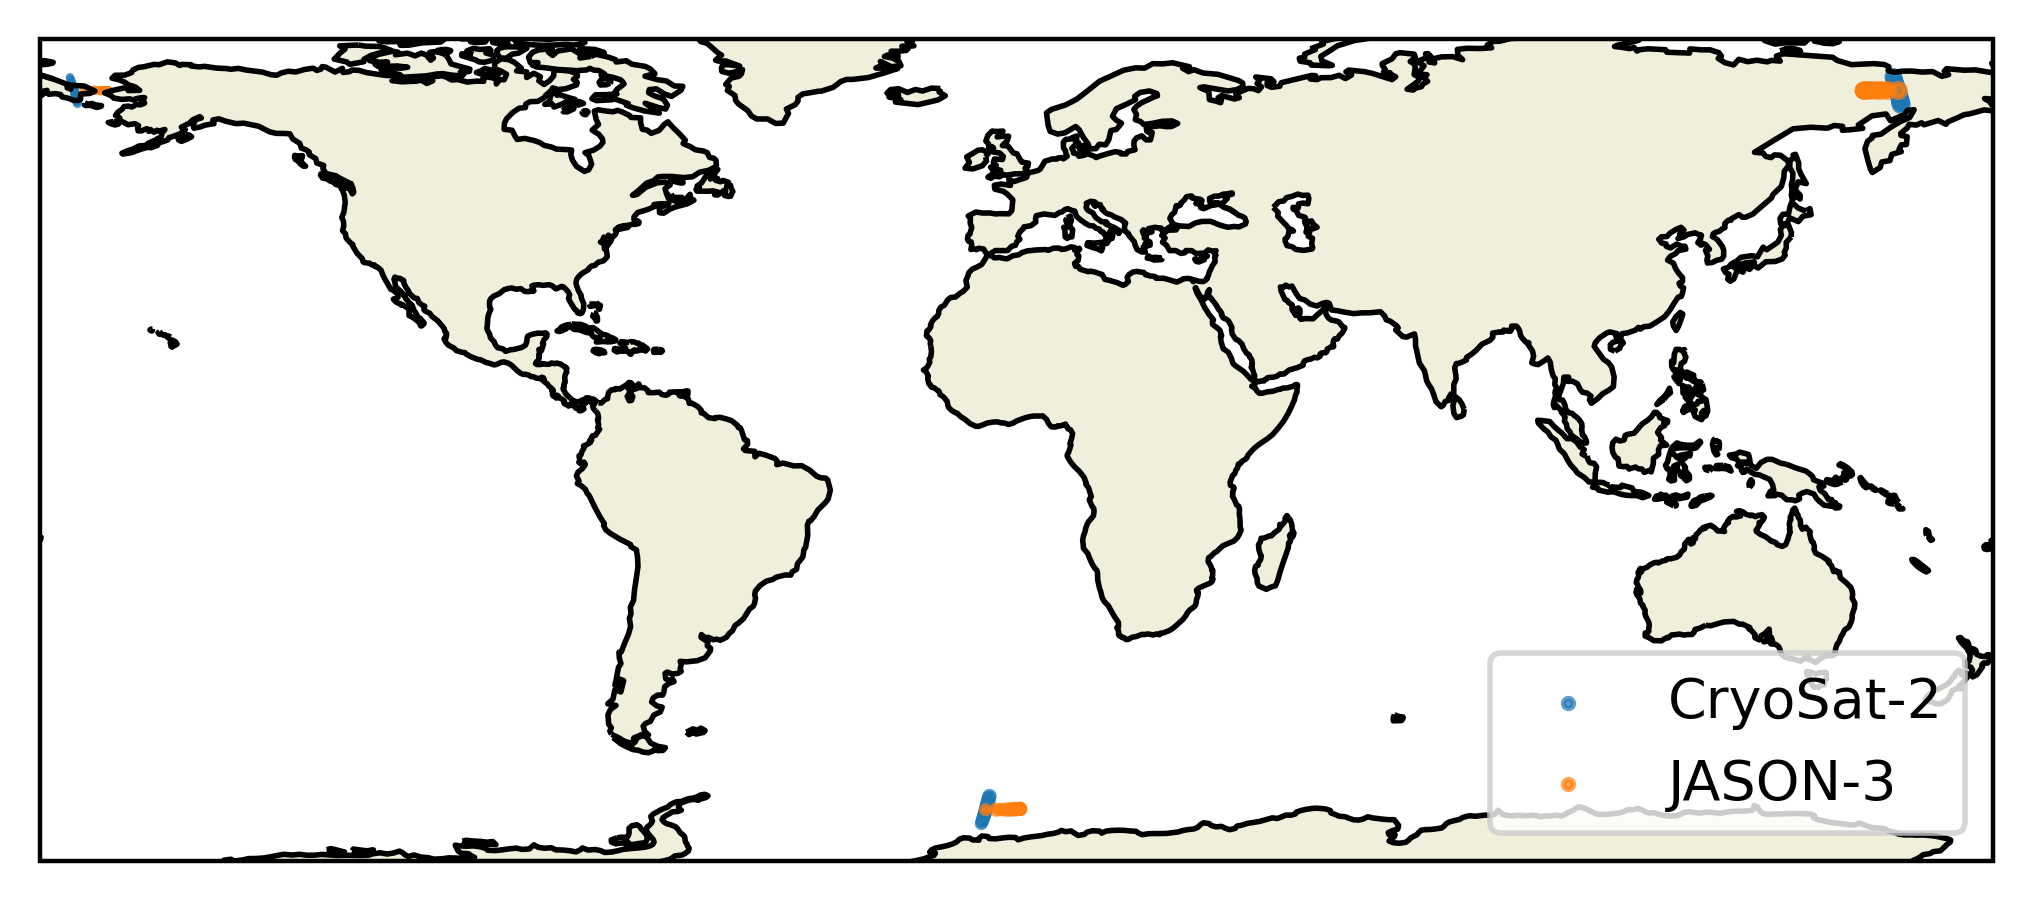

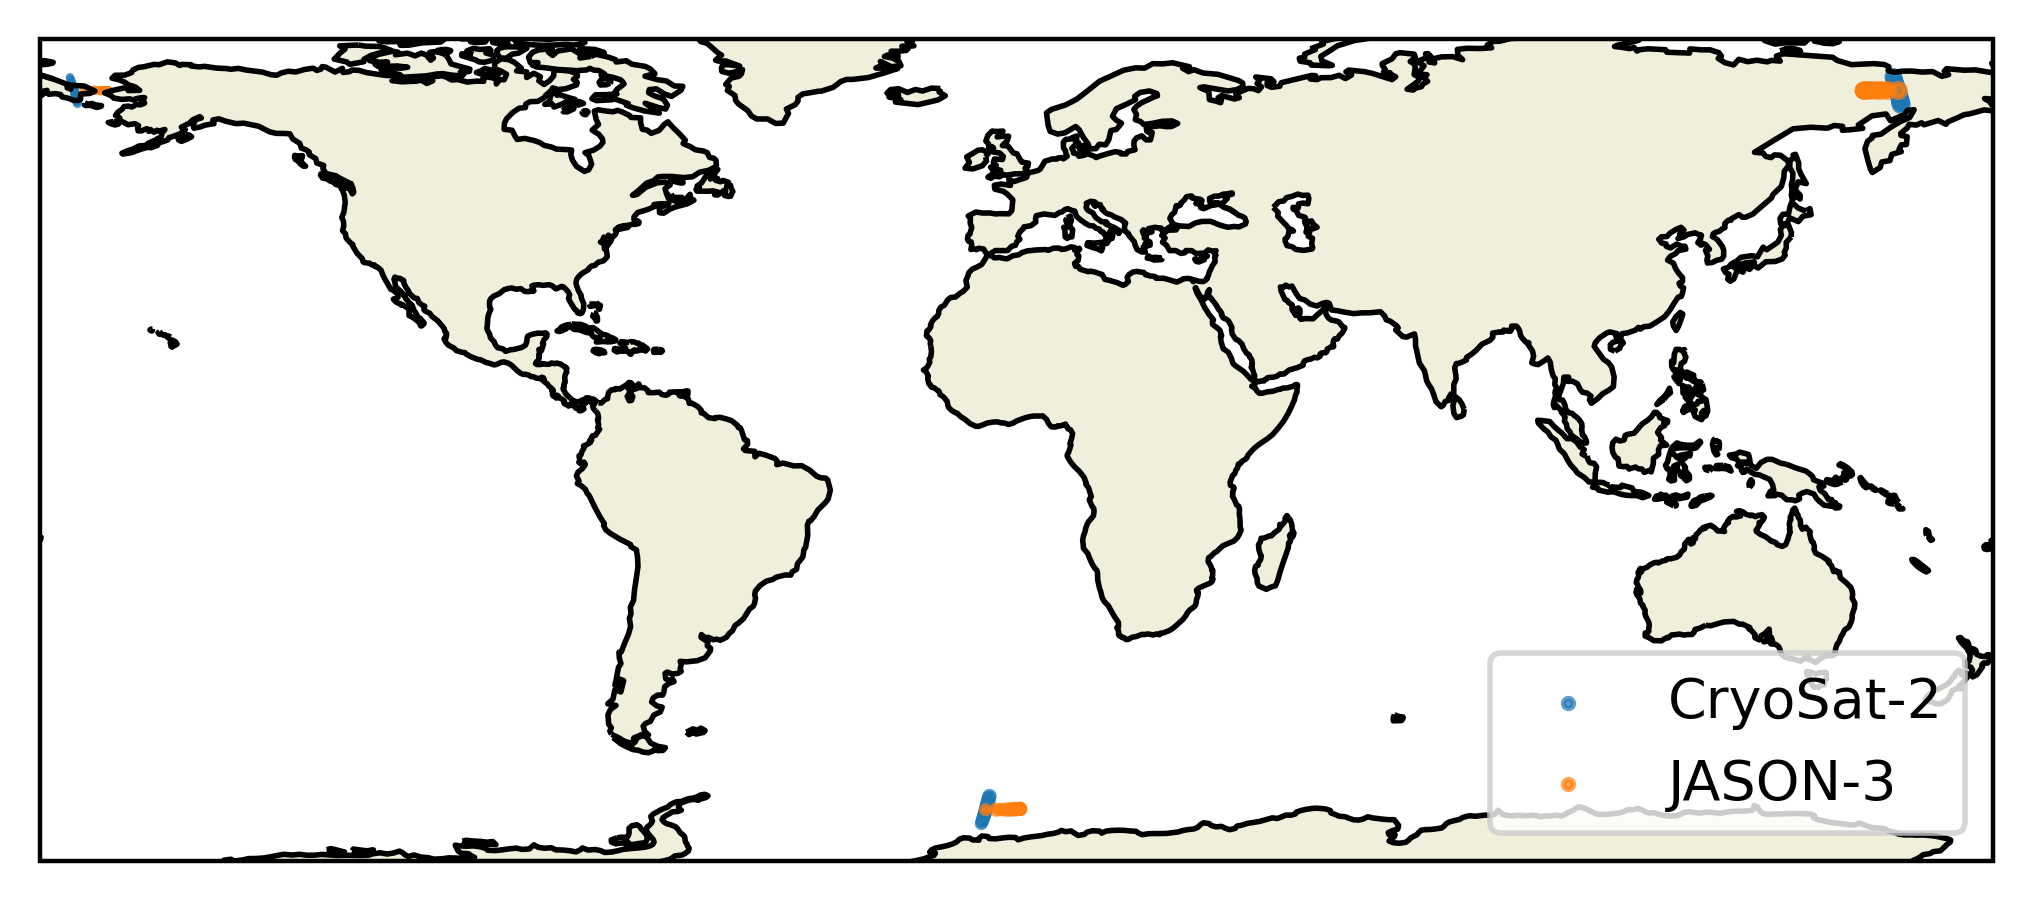

In [6]:
matchups.plot()

In [8]:
matchups.to_netcdf("./test_export/")

In [20]:
from orbitx import Matchups
loaded_matchup = Matchups.from_netcdf("./test_export/2012-01-01_2012-01-01_psi60.0_isi5.0_matchups_CS2_J3_c2c290.0_tdt900.0.nc")

C:\Users\xl3\Documents\projects\orbitx\orbitx\tle.py:141: UserWarning: The oldest TLE file is more recent than the start time requested.
 Oldest TLE file: 2016-01-18T20:22:02.081
 Start time requested: 2011-12-31T23:45:00
  warnings.warn(


In [ ]:
print(matchups == loaded_matchup)

True
True
True
True
True
True
True
True
True
True
True
